### Test notebook

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import EMSigma_baseline_without_bug as EM0_base
import EMSigma_3_20_26 as EM0

In [2]:
#test vectors
a, theta_a = 2.0, np.pi/3.0
b, theta_b = 3.0, np.pi/4.0
c, theta_c = 4.0, np.pi/6.0

print("Baseline    :", EM0_base.add_sub_vec_mag(a, theta_a, b, theta_b, c, theta_c))
print("Updated Code:",EM0.add_sub_vec_mag(a, theta_a, b, theta_b, c, theta_c))

Baseline    : 1.8848033382770102
Updated Code: 1.8848033382770102


Baseline    : 0.0
Updated Code: 0.0


/mnt/ffs24/home/smit3843/Documents/EMsigma_Cleaned/Baseline_Code_Jupyter_Notebook/EMSigma_baseline_without_bug.py:175: RuntimeWarning: divide by zero encountered in divide
  arg = (1 + np.exp((r - C_m_p)/a_m_p))
/mnt/ffs24/home/smit3843/Documents/EMsigma_Cleaned/Baseline_Code_Jupyter_Notebook/EMSigma_3_20_26.py:98: RuntimeWarning: divide by zero encountered in divide
  return rho_0_p /(1 + np.exp((r - C_m_p)/a_m_p))


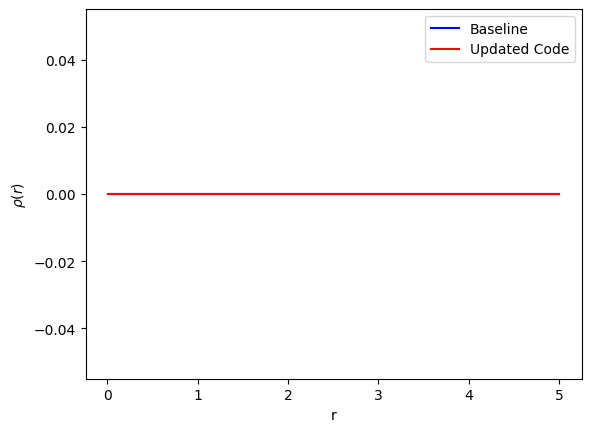

In [3]:
test_mesh = np.linspace(0.01,5, 30)
print("Baseline    :", EM0_base.rho_m(test_mesh )[-1])
print("Updated Code:", EM0.rho_m(test_mesh )[-1])

plt.plot(test_mesh, EM0_base.rho_m(test_mesh ), color = "blue", label = "Baseline")
plt.plot(test_mesh, EM0.rho_m(test_mesh ), color = "red", label = "Updated Code")
plt.xlabel("r")
plt.ylabel(r"$\rho(r)$")
plt.legend()
plt.show()

### $\Gamma(b)$ Section

In [4]:
b = 3.0
print("Baseline    :", EM0_base.Gamma(b))

test_gamma = EM0.Profile_Function(Model_type = "general")
test_gamma.alpha = 1.808
test_gamma.beta =  .268 
test_gamma.sigma_n = 3.16

print("Updated Code:", test_gamma.Gamma(b))


Baseline    : (4.7872304350836485e-08-8.655312626631236e-08j)
Updated Code: (4.7872304350836485e-08-8.655312626631235e-08j)


In [5]:
E = 325 #MeV
EM0_base.profile_funct_param(E, interaction_type = "matter")

test_gamma = EM0.Profile_Function(Model_type = "matter", E = 325)


#What is going on 

Gamma_W = lambda b:  (1 - 1j * 0.305) / (4 * np.pi * 0.075) * 3.03 * np.exp(-b**2 / (2 * 0.075))

b = 3.0
print("Baseline    :", EM0_base.Gamma(b))
print("Updated Code:", test_gamma.Gamma(b))
print("test test   :", Gamma_W(b))

Baseline    : (2.815156783683478e-26-8.586228190234607e-27j)
Updated Code: (2.815156783683478e-26-8.586228190234607e-27j)
test test   : (2.815156783683478e-26-8.586228190234607e-27j)


In [6]:
E = 300 #MeV
EM0_base.profile_funct_param(E, interaction_type = "np")

test_gamma = EM0.Profile_Function(Model_type = "np", E = 300)

b = 3.0
print("Baseline    :", EM0_base.Gamma(b))
print("Updated Code:", test_gamma.Gamma(b))

Baseline    : (2.7104334286135547e-24-8.836071405087366e-25j)
Updated Code: (2.7104334286135547e-24-8.836071405087364e-25j)


### Cross section 

Baseline    : 0.8433016800849248
Updated Code: 0.8433016800849248


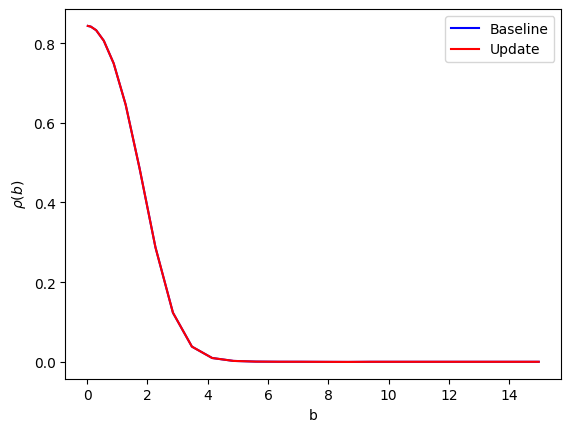

In [7]:
#Loading the densites
C = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-mass.txt", unpack= True) 
C_r_mesh = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12C_radius.txt", unpack= True)

C_rho_baseline = EM0_base.dens_b_interpolator(C_r_mesh[0],C[0])
C_rho_update = EM0.dens_b_interpolator(C_r_mesh[0],C[0])

print("Baseline    :", C_rho_baseline[0])
print("Updated Code:", C_rho_update[0])

plt.plot(EM0_base.t_mapped_roots.tolist(),C_rho_baseline, color = "blue", label = "Baseline")
plt.plot( EM0.t_mapped_roots.tolist(),C_rho_update, color = "red", label = "Update")

plt.xlabel("b")
plt.ylabel(r"$\rho(b)$")
plt.legend()
plt.show()

In [8]:
b = 3.0
print("Baseline    :", EM0_base.rhoz_p(b))
print("Updated Code:", EM0.rhoz_p(b))

Baseline    : 0.0
Updated Code: 0.0


In [9]:
#Load in densities
C_r_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/12C_radius.txt",])     
C_p_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-prot.txt",])
C_n_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-neut.txt",])
C_p = np.genfromtxt(C_p_Filename[0], unpack= True)
C_r_mesh = np.genfromtxt(C_r_Filename[0], unpack= True)
C_n = np.genfromtxt(C_n_Filename[0], unpack= True)

C_rho_p = EM0.dens_b_interpolator(C_r_mesh[0], C_p[0]) 
C_rho_n = EM0.dens_b_interpolator(C_r_mesh[0], C_n[0])

Ca_r_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/42Ca_radius.txt",])     
Ca_p_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/42Carho-prot.txt",])
Ca_n_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/42Carho-neut.txt",])
Ca_p = np.genfromtxt(Ca_p_Filename[0], unpack= True)
Ca_r_mesh = np.genfromtxt(Ca_r_Filename[0], unpack= True)
Ca_n = np.genfromtxt(Ca_n_Filename[0], unpack= True)

Ca_rho_p = EM0.dens_b_interpolator(Ca_r_mesh[0], Ca_p[0]) 
Ca_rho_n = EM0.dens_b_interpolator(Ca_r_mesh[0], Ca_n[0])


In [10]:
b = 3
rho_t = C_rho_p + C_rho_p
rho_p = Ca_rho_p +Ca_rho_n

EM0_base.profile_funct_param(E, interaction_type = "matter")
test_gamma = EM0.Profile_Function(Model_type = "matter", E = E)

print("Baseline    :", EM0_base.Chi_mol_1(b, rho_t, rho_p, EM0_base.Gamma))
print("Updated Code:",EM0.Chi_mol_1(b, rho_t, rho_p, test_gamma.Gamma))

Baseline    : (0.9073349462171986+3.6729755575184617j)
Updated Code: (0.9073349462171986+3.6729755575184617j)


In [11]:
print("Baseline    :", EM0_base.Chi_mol(b, rho_t, rho_p, EM0_base.Gamma))
print("Updated Code:",EM0.Chi_mol(b, rho_t, rho_p, test_gamma.Gamma))

Baseline    : (1.4937095544003078+6.7492955967660695j)
Updated Code: (1.4937095544003078+6.7492955967660695j)


In [12]:
print("Baseline    :", EM0_base.chi(b, rho_t, rho_p, EM0_base.Gamma))
print("Updated Code:", EM0.chi(b, rho_t, rho_p, test_gamma.Gamma))

Baseline    : (3.6653180164346435+9.995518116197603j)
Updated Code: (3.6653180164346435+9.995518116197603j)


In [14]:
print("Baseline:",EM0_base.chi_no_dens(b , rho_t, EM0_base.Gamma)) 
print("Updated Code:",EM0.chi_no_dens(b , rho_t, EM0_base.Gamma)) 


Baseline: (0.03813593629622238+0.10399873637645259j)
Updated Code: (0.03813593629622238+0.10399873637645259j)


In [15]:
print("Baseline    :",EM0_base.sigma_R( rho_t,  rho_p  = rho_p , Gamma = EM0_base.Gamma, Model = "MOL"))
print("Updated Code:",EM0.sigma_R_matter( rho_t,  rho_p  = rho_p , Gamma = test_gamma.Gamma, Model = "MOL"))

Baseline    : 1463.5634452220208
Updated Code: 1463.5634452220208


In [16]:
print("Baseline    :",EM0_base.sigma_R( rho_t,  rho_p  = rho_p , Gamma = EM0_base.Gamma, Model = "OLA"))
print("Updated Code:",EM0.sigma_R_matter( rho_t,  rho_p  = rho_p , Gamma = test_gamma.Gamma, Model = "OLA"))


Baseline    : 1504.2941007031006
Updated Code: 1504.2941007031006


In [17]:
E = 300 #MeV
EM0_base.profile_funct_param(E, interaction_type = "np")
test_gamma = EM0.Profile_Function(Model_type = "np", E = 300)

print("Baseline    :",EM0_base.sigma_R( rho_t,  rho_p  = 0, Gamma =EM0_base.Gamma , Model = "OLA p-n"))
print("Updated Code:",EM0.sigma_R_matter( rho_t,  rho_p  = 0, Gamma = test_gamma.Gamma, Model = "OLA p-n"))


Baseline    : 247.44280936757912
Updated Code: 247.44280936757912


In [18]:
b = 3
rho_t_p = C_rho_p 
rho_t_n = C_rho_n
rho_p_p = Ca_rho_p 
rho_p_n = Ca_rho_n

print("Baseline    :",EM0_base.chi_mol_micro(b, rho_t_p, rho_t_n, rho_p_n,rho_p_p, EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap))
print("Updated Code:",EM0.chi_mol_micro(b, rho_t_p, rho_t_n, rho_p_n,rho_p_p, EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap))


Baseline    : (2.7947557825163045+8.141000404457593j)
Updated Code: (2.7947557825163045+8.141000404457593j)


In [19]:
print("Baseline    :", EM0_base.chi_ola_micro(b, rho_t_p, rho_t_n, rho_p_n,rho_p_p, EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap) )
print("Updated Code:", EM0.chi_ola_micro(b, rho_t_p, rho_t_n, rho_p_n,rho_p_p, EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap))

Baseline    : (4.416526727148977+9.93387753338015j)
Updated Code: (4.416526727148977+9.93387753338015j)


In [20]:
print("Baseline    :",EM0_base.sigma_R_micro(rho_t_p, rho_t_n, rho_p_p, rho_p_n, 
                             EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap , Model = "OLA"))
print("Updated Code:",EM0.sigma_R_pn(rho_t_p, rho_t_n, rho_p_p, rho_p_n, 
                             EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap, Model = "OLA"))



Baseline    : 1498.5621242348552
Updated Code: 1498.5621242348552


In [21]:
print("Baseline    :",EM0_base.sigma_R_micro(rho_t_p, rho_t_n, rho_p_p, rho_p_n, 
                             EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap , Model = "MOL"))
print("Updated Code:",EM0.sigma_R_pn(rho_t_p, rho_t_n, rho_p_p, rho_p_n, 
                             EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap  , Model = "MOL"))

Baseline    : 1478.847055234457
Updated Code: 1478.847055234457
